# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías

In [2]:
# cargar archivos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [3]:

# mostrar las primeras 5 filas de plans
plans.head(5)


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape )
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print((users).isna().sum().sort_values(ascending = False)) # Cantidad de valores nulos)
print()
print((users).isna().mean().sort_values(ascending = False))# Proporción de valores nulos)

churn_date    3534
city           469
user_id          0
first_name       0
last_name        0
age              0
reg_date         0
plan             0
dtype: int64

churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [11]:
# cantidad de nulos para usage
print((usage).isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  
    **La fecha de Cancelacion es la columna con mayor cantidad de valores nulos, pero considero no es una columna relevante para el analisis, por lo cual  City con 469 faltantes que representan el 11.7% de los datos si requieren atencion.**
  
- Indica qué harías: ¿imputar, eliminar, ignorar?

  
   **Para este caso, lo ideal seria imputar los datos de la columna City**

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users

In [13]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` **Para user_id no detecto ningun valor que requiera alguna atencion especial**
- La columna `age` **Con respecto a la columna age, se detecta que su valor minimo es un valor negativo (-999), lo cual indica algunos valores invalidos y posibles outliers**

In [14]:
# explorar columnas numéricas de usage

- Las columnas `id` y `user_id`** no presentan ningun valor que requiera atencion especial**
- Las columnas **duration y length contienen valores nulos o vacios, los cuales requieren procesamiento en caso de que se necesite para analisis y presentacion de la infromacion** 

In [15]:
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

- La columna `city` **presenta valores 96 valores ausentes (?), lo cual requerira algun tratamiento especial**
- La columna `plan` **no presenta ningun valor ausente, por lo cual no requiere tratamiento**

In [17]:
print("Ciudades únicas:")
print(users['city'].unique())
print(f"\nTotal de ciudades: {users['city'].nunique()}")

# Contar frecuencias
print("\nFrecuencia por ciudad:")
print(users['city'].value_counts())

# Ver en porcentajes
print("\nPorcentajes por ciudad:")
print(users['city'].value_counts(normalize=True) * 100)

Ciudades únicas:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Total de ciudades: 7

Frecuencia por ciudad:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Porcentajes por ciudad:
Bogotá      22.883036
CDMX        20.674030
Medellín    17.445483
GDL         12.744265
Cali        12.007930
MTY         11.526480
?            2.718777
Name: city, dtype: float64


In [18]:
# Ver planes únicos
print("Planes disponibles:")
print(users['plan'].unique())

# Distribución de planes
print("\nDistribución de planes:")
print(users['plan'].value_counts())
print("\nPorcentajes:")
print(users['plan'].value_counts(normalize=True) * 100)

Planes disponibles:
['Basico' 'Premium']

Distribución de planes:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Porcentajes:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


In [19]:
# explorar columna categórica de usage
usage['type'] # completa el código

0        call
1        text
2        text
3        call
4        call
         ... 
39995    call
39996    call
39997    call
39998    text
39999    call
Name: type, Length: 40000, dtype: object

- La columna `type` **no presenta valores ausentes**


In [20]:
print("Tipos de uso:")
print(usage['type'].unique())

# Frecuencias
print("\nFrecuencia por tipo:")
print(usage['type'].value_counts())

Tipos de uso:
['call' 'text']

Frecuencia por tipo:
text    22092
call    17908
Name: type, dtype: int64


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

  **De acuerdo a la revision de los valores de cada dataframe, las columnas que requieren atencion por valores ausentes o invalidos son las siguientes por dataframe**

  *Plans (age)*
  *User (city)*
  *usage (duration y length)*
  
- ¿Qué acción tomarías?

  **De acuerdo a la necesidad, se imputrara las columnas que requieran ser atendidas, con los valores estadisticos que se puedan caluclar**

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [21]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date']) # completa el código

In [22]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date']) # completa el código

In [23]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, **se encontraron fechas del 2026, lo que de acuerdo a las instrucciones al inicio del proyecto indicaba que solo que tenia informacion hasta el año 2024, por lo cual seguramente sean valores mal ingresados**

In [24]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

  **Para el dataframe de usage, en la columna de ´date´ no hay años superiores a los indicados en el proyecto, por lo cual no requieren ningun tipo de tratamiento ni limpieza**
  
- ¿Qué harías con ellas?

  **Para el dataframe de usage, no se realizara ningun ajuste de la informacion**

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [25]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", "NA")

# Verificar cambios
print(users['city'].value_counts())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
NA           96
Name: city, dtype: int64


In [27]:
# Marcar fechas futuras como NA para reg_date

fechas_futuras = users['reg_date'].dt.year > 2024

# Reemplazar esas fechas con pd.NaT (Not a Time)
users.loc[fechas_futuras, 'reg_date'] = pd.NaT

# Verificar cambios
print("Años después de la limpieza:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años después de la limpieza:
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [28]:
# Verificación MAR en usage (Missing At Random) para duration


print("Valores nulos en duration por tipo:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

# 2. Ver la relación en porcentajes
print("\nPorcentaje de nulos en duration por tipo:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean() * 100))

# 3. Crear tabla cruzada para visualizar mejor
tabla_cruzada = pd.crosstab(usage['type'], usage['duration'].isna(), margins=True)
print("\nTabla cruzada (type vs duration nula):")
print(tabla_cruzada)



Valores nulos en duration por tipo:
type
call        0
text    22076
Name: duration, dtype: int64

Porcentaje de nulos en duration por tipo:
type
call     0.000000
text    99.927576
Name: duration, dtype: float64

Tabla cruzada (type vs duration nula):
duration  False   True    All
type                         
call      17908      0  17908
text         16  22076  22092
All       17924  22076  40000


In [29]:
# Verificación MAR en usage (Missing At Random) para length
print("Valores nulos en duration por tipo:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

# 2. Ver la relación en porcentajes
print("\nPorcentaje de nulos en length por tipo:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean() * 100))

# 3. Crear tabla cruzada para visualizar mejor
tabla_cruzada = pd.crosstab(usage['type'], usage['length'].isna(), margins=True)
print("\nTabla cruzada (type vs length nula):")
print(tabla_cruzada)

Valores nulos en duration por tipo:
type
call    17896
text        0
Name: length, dtype: int64

Porcentaje de nulos en length por tipo:
type
call    99.932991
text     0.000000
Name: length, dtype: float64

Tabla cruzada (type vs length nula):
length  False   True    All
type                       
call       12  17896  17908
text    22092      0  22092
All     22104  17896  40000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Los valores nulos que se encuentran en el dataframe de 'usage' son MAR, ya que 'duration' y 'length' dependen de la columna ´type', debido a que la duracion, se refiere a las llamadas, y por ende los mensajes no podrian tener duracion, en cuanto a la longitud, pasa lo mismo (me imagino que se refiere a los caracteres), no podrian tener longitud una llamda, ya que su medicion es en tiempo**

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [30]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',  
    'duration': 'sum'       
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users, on='user_id')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [33]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,5.524381,4.478120,23.317054,48.124531
std,1154.898108,2.358416,2.144238,18.168095,17.692032
min,10000.000000,0.000000,0.000000,0.000000,18.000000
25%,10999.500000,4.000000,3.000000,11.120000,33.000000
50%,12000.000000,5.000000,4.000000,19.780000,47.000000
75%,12999.500000,7.000000,6.000000,31.415000,63.000000
max,13999.000000,17.000000,15.000000,155.690000,79.000000


In [34]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

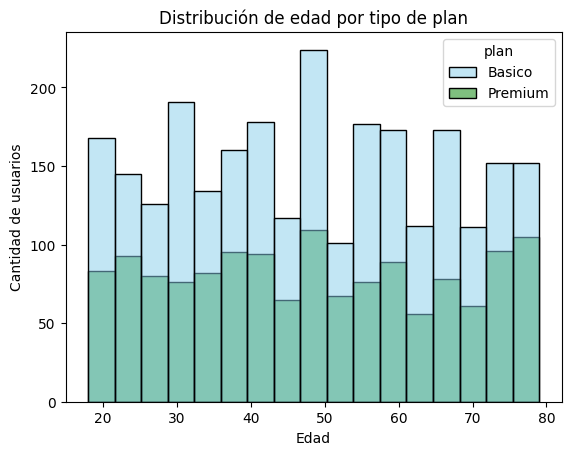

In [35]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de edad por tipo de plan')
plt.show()


💡Insights: 
**- Distribución simetrica, no se observa una tendencia hacia alguno de los costados del histogrma, existe una proporcion similar entre los dos planes con respecto a todas las edades, pero si puede observarse que los clientes con edad de 50 años, tienen una mayor cantidad de llamadas y mensajes con respecto a otras edades**

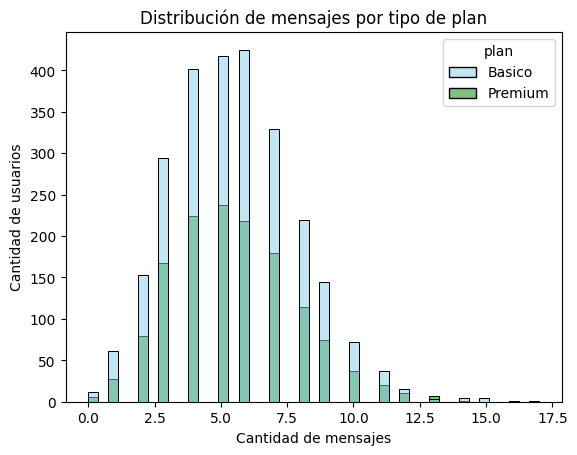

In [36]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de mensajes por tipo de plan')
plt.show()


💡Insights: 
- **El histograma muestra una distribucion con un ligero sesgo hacia la derecha, se mantiene una proporcion entre los dos planes muy similar de acuerdo a la cantidad de mensajes enviados, pero se observa que en los dos planes la mayoria de los clienes envia en promedio 5 mensajes por periodo**

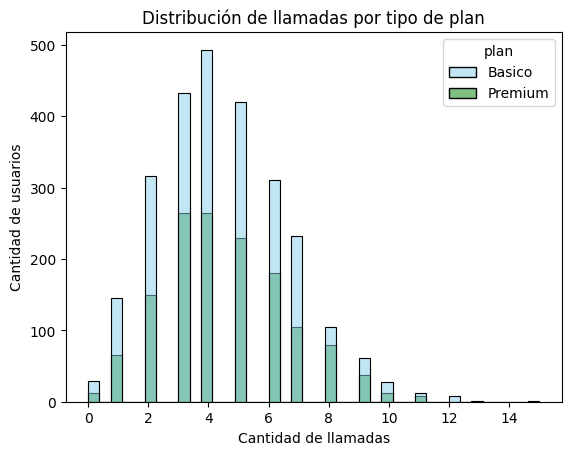

In [37]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de llamadas por tipo de plan')
plt.show()


💡Insights: 
- **Nuevamente se muestra una Distribución ligeramente desgada a la derecha, con proporciones similares entre los dos planes con respecto a la cantidad de llamadas, pero se observa que la mayoria de los usuarios realizar en promedio 4 llamadas por periodo**

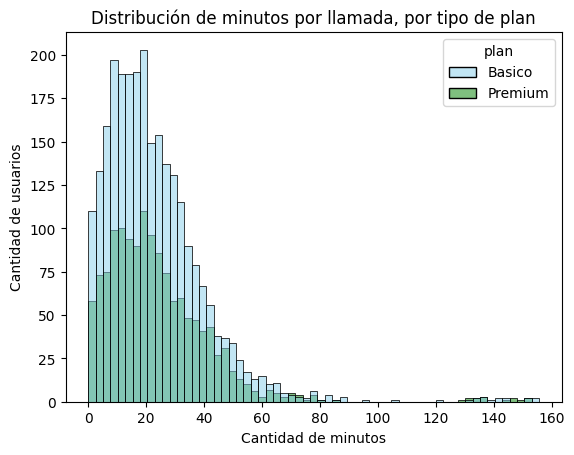

In [38]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.xlabel('Cantidad de minutos')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de minutos por llamada, por tipo de plan')
plt.show()

💡Insights: 
-**Distribucion sesgada a la derecha, con proporciones similares entre los dos planes, en el que se obcerva que la mayor cantidad de usuarios habra en promedio 20 minutos por periodo, tambien se observan que hay valores muy lejanos al proemdio, con mas de 120 minunos, lo que pordian considerarse posibles outliers**

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

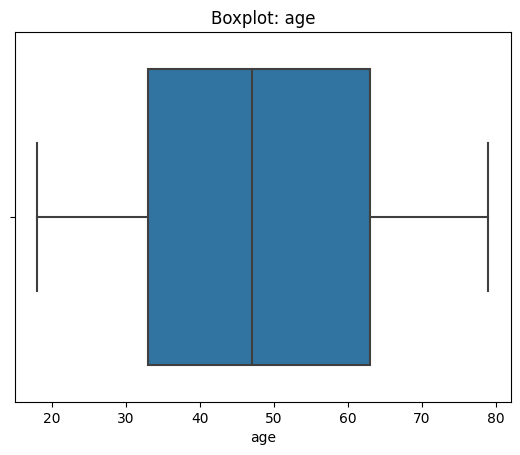

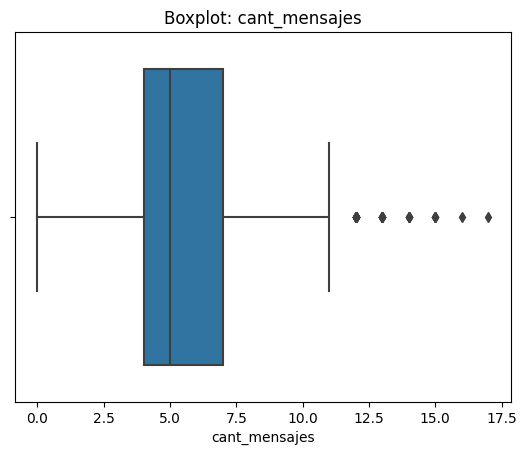

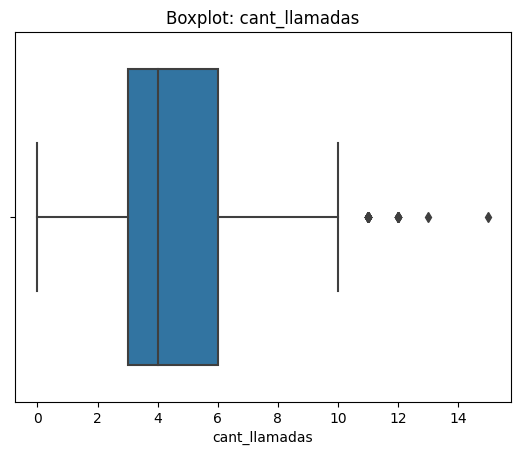

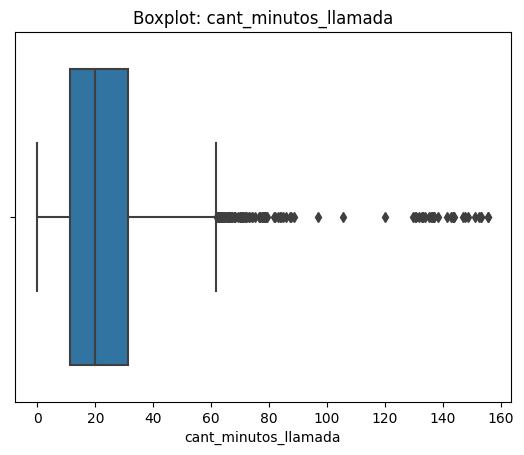

In [39]:

# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:

    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()



💡Insights: 
- Age:  **No presenta outliers**
- cant_mensajes: **Se obcervan muy pequeños puntos fuera de los "bigotes" del Boxpltos, que podrian considerarse como outliers**
- cant_llamadas: **Se obcervan muy pequeños puntos fuera de los "bigotes" del Boxpltos, que podrian considerarse como outliers**
- cant_minutos_llamada: **En este caso, se aprecia una concentracion inportante fuera de los "bigotes" al extremo derecho, que son evidentemente outliers**

In [40]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    print("Limite:",col,upper)



Limite: cant_mensajes 11.5
Limite: cant_llamadas 10.5
Limite: cant_minutos_llamada 61.8575


In [41]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?

  **En este caso mantener para la cantidad de mensajes se puede mantener ya que son valores reales de algun evento en especifico**

  
- cant_llamadas: mantener o no outliers, porqué?

- 
  **Para la cantidad de Llamadas tambien es necesario mantener ya que son valores reales por algun evento en especifico**


- cant_minutos_llamada: mantener o no outliers, porqué?

- 
  **Para la cantidad de minutos por llamda, a pesar de que puede ser un valor real y no se debe a algun tema de error de captura, podriamos capar o winsorizar los vzalores al percentil 99**

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [42]:
# Crear columna grupo_uso

user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)


In [43]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [44]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    (user_profile['age'] < 30), 
    'Joven',
    np.where(
        (user_profile['age'] < 60),
        'Adulto',
        'Adulto Mayor'
    )
)

In [45]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


In [52]:
print(user_profile['grupo_edad'].value_counts(normalize=True) * 100)

Adulto          50.437609
Adulto Mayor    30.557639
Joven           19.004751
Name: grupo_edad, dtype: float64


In [53]:
print(user_profile['grupo_uso'].value_counts(normalize=True) * 100)

Uso medio    73.593398
Bajo uso     19.454864
Alto uso      6.951738
Name: grupo_uso, dtype: float64


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

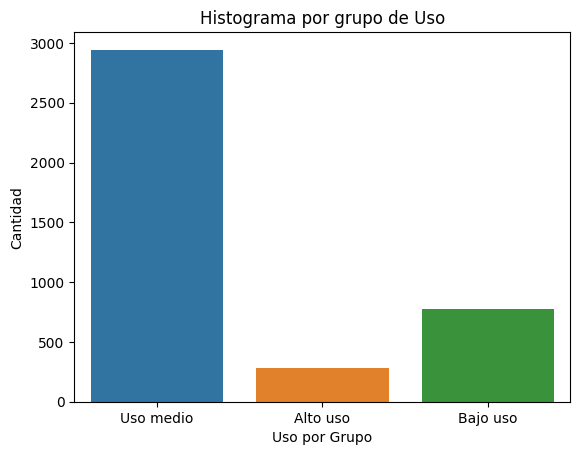

In [46]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Histograma por grupo de Uso')
plt.xlabel('Uso por Grupo')
plt.ylabel('Cantidad')
plt.show()

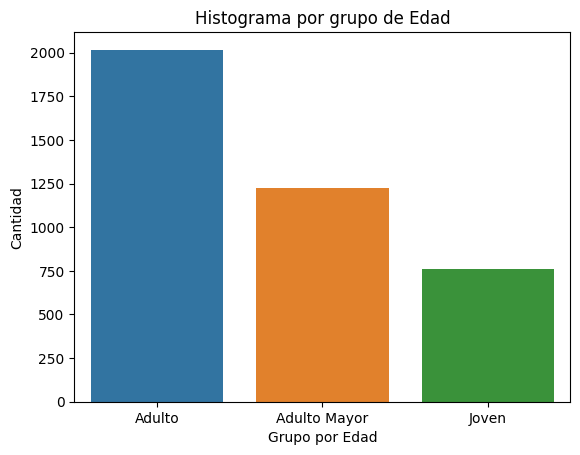

In [47]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Histograma por grupo de Edad')
plt.xlabel('Grupo por Edad')
plt.ylabel('Cantidad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

    **La informacion se encontraba en tres dataframe separados, los cuales contaban con informacion ausente en algunos casis, asi como valores nulos. En el data frame de 'users' se tenia casi el 12% de valores ausentes en la columna 'city'**

   
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

      **Se segmentaron en tres grupos (joven, Adulto y Adulto Mayor), los cuales de acuerdo a la informacion grafica mostrada se encuentra la mayor propocion de clientes dentro del grupo de nivel de uso medio**


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

    **El Grupo de Adultos menores a 60 años**


- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

    **Se detecto principalmente que la cantidad de minutos por llamda, generaban outliers, lo cual para datos estadisticos como el promedio de minutos de llamada contaminaba el resto de la informacion**


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

    **Diseñar un plan de nivel medio, enfocado principlamnete para adultos**

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**


**-Errores en los dataframe, ya sea por valores ausentes, edades invalidas, fechas futuras**
**-Procesamiento de informacion en de los valores nulos en el tipo de comunicacion**

🔍 **Segmentos por Edad**


**-Se obcerva que el grupo con mayor actividades de servicio para ConnetcaTel es el de Adultos menores a 60 años con una proporcion del 50%**
**-El segmento con menores servicios utilizados es el de Adultos Mayores, con el 19%**


📊 **Segmentos por Nivel de Uso**


**-Para el analisis usuarios con menos de 5 llamadas y 5 mensajes se les asigno un segmento como de Bajo uso**
**-Para usuarios con 10 o mas mensjaes y lalamdas, se consideraron como Uso Alto**


➡️ Esto sugiere que 

**Nuestro cliente base se encuntra en adutlos menores a 60 años con el 50% del mercado , con usos medios de mas del 73%**


💡 **Recomendaciones**


**-Diseñar un plan exclusivo para minutos de llamdas muy prolongados, para algun segmento especial en un plan adecuado**
**-Insentivar a los jovenes menores de 30 años al uso de llamdas y mensajes, ya que seguramente su principal medio de comunicacion son las redes sociales**

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`